# LFY032 Föreläsning 4
Fredrik Skärberg, 2024

# Idag

* Frågor om laboration 3.
* Laboration 4 kommer att publiceras imorgon onsdag 2024-11-13
---

* Arv för klasser i Python och några exempel
* "Speciella" metoder för klasser i Python
---
* Genomgång om projekt info/krav etc.

* *Osäkerhet för neurala nät (Exempelprojekt 1)*
    * Sannolikhetsfördelningar
    * Härleda en egen loss-funktion
    * Träna en sannolikhetsbaserad modell
    
* *Prediktera försäkringspremie med neurala nät (Exempelprojekt 2)*
    * Träna ett ANN.
    
* *Prediktera ett aktiepris givet historisk data med neurala nät (Exempelprojekt 3)*
    * Träna ett 1D-CNN
---
* Quiz på mentimeter: **3232 7703**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Definition av en klass

In [3]:
class Person:
    def __init__(self, name, age):
        self.name = name
        self.age = age
        
    def say_age(self):
        print(f"I am {self.age} years old.")
        
    def say_name(self):
        print(f"My name is {self.name}.")
        
    def greet(self):
        self.say_name()
        self.say_age()

In [6]:
p = Person(name='Hans', age=18)
p.greet()

My name is Hans.
I am 18 years old.


# Arv

Arv "ärva" (inherit) är en mekanism som tillåter en klass (kallad "subklass" eller "child class") att ärva egenskaper och metoder från en annan klass (kallad "superklass" eller "parent class").

Detta kan vara användbart när många objekt delar gemensamma egenskaper.

Konceptet finns i alla objektorienterade språk såsom C++, JAVA, Python 

In [8]:
class BasKlass:
    def metod(self):
        print("Jag är metod() från BasKlass")
        
class NyKlass(BasKlass):
    def en_annan_metod(self):
        print("Jag är en_annan_metod() från NyKlass")

objekt = NyKlass()
objekt.metod()
objekt.en_annan_metod()

Jag är metod() från BasKlass
Jag är en_annan_metod() från NyKlass


En klass som ärver av en annan klass kallas **härledd** (derived class, child class). 

När vi refererar till klassen som vi ärver från så är det vanligt att använda **förälder** (parent class) eller **bas** (base class).

## Överlagring
En härledd klass kan implementera nya versioner av metoder i basklassen.

Detta kallas också överskuggning, där Subklasser kan överskugga (override) metoder som ärver från överordnade klasser. Detta innebär att subklassen kan tillhandahålla sin egen implementation av en metod med samma namn.

In [11]:
class BasKlass:
    def metod(self):
        print("Jag är metod() från BasKlass")
        
class HärleddKlass(BasKlass):
    def metod(self):
        print("Jag är metod() från HärleddKlass")

objekt = HärleddKlass()
objekt.metod()

Jag är metod() från HärleddKlass


## Exempel: Definera djur

In [12]:
# Bas-klass (överklass)
class Djur:
    def __init__(self, namn, ålder):
        self.namn = namn 
        self.ålder = ålder

    def äta(self):
        print(f"{self.namn} äter mat.")
    
    def sova(self):
        print(f"{self.namn} sover.")

# Underklass som ärver från Djur-klassen
class Hund(Djur):
    def skäll(self):
        print(f"{self.namn} skäller: Woof! Woof!")

# Underklass som ärver från Djur-klassen
class Katt(Djur):
    def spinna(self):
        print(f"{self.namn} spinner: Purr, purr!")

In [14]:
# Skapa instanser av underklasserna
fido = Hund("Fido", 3)
whiskers = Katt("Whiskers", 5)

# Använda metoder från bas-klassen
fido.äta()  # Anropar äta-metoden från Djur-klassen
whiskers.äta()

# Använda metoder från underklasserna
fido.skäll()  # Anropar skäll-metoden som är specifik för Hund-klassen
whiskers.spinna()  # Anropar spinna-metoden som är specifik för Katt-klassen

Fido äter mat.
Whiskers äter mat.
Fido skäller: Woof! Woof!
Whiskers spinner: Purr, purr!


In [17]:
#whiskers.skäll() #Funkar ej

## Exempel: geometriska former

In [18]:
class Form:
    def area(self):
        print("Alla former måste implementera area()!")
        
    def namn(self):
        print("Alla former måste implementera namn()!")
        
    def print_area(self):
        area = round(self.area(), 3)
        form = self.namn()
        print(f"Denna {form} har area {area}")

In [19]:
class Cirkel(Form):
    def __init__(self, radie):
        self.radie = radie
        
    def namn(self):
        return "cirkel"
        
    def area(self):
        return math.pi * self.radie**2
    
class Kvadrat(Form):
    def __init__(self, sida):
        self.sida = sida
        
    def namn(self):
        return "kvadrat"
        
    def area(self):
        return self.sida**2
    

In [23]:
#cirkel = Cirkel(4)
#cirkel.print_area()

kvadrat = Kvadrat(10)
kvadrat.print_area()

Denna kvadrat har area 100


## Konstruktorer

I Python kallas inte basklassens konstruktor automatiskt utan vi måste göra detta explicit. För att komma åt basklassens instans så finns funktionen `super()`.

In [26]:
class BasKlass:
    def __init__(self):
        print("Konstruktor för basklass")
        
class HärleddKlass(BasKlass):
    def __init__(self):
        super().__init__() #Kallas då objektet skapas.
        print("Konstruktor för härledd klass")
        
objekt = HärleddKlass()

Konstruktor för basklass
Konstruktor för härledd klass


In [30]:
class Person:
    def __init__(self, förnamn, efternamn):
        self.förnamn = förnamn
        self.efternamn = efternamn

    def presentera_sig(self):
        return f"Hej, jag heter {self.förnamn} {self.efternamn}"

class Student(Person):
    def __init__(self, förnamn, efternamn, program):
        super().__init__(förnamn, efternamn)  # Anropa överklassens konstruktor
        self.program = program
        
    def presentera_sig(self):
        return f"Hej, jag heter {self.förnamn} {self.efternamn} och jag studerar {self.program}"

In [29]:
# Skapa instanser av Person- och Student-klasserna
#person1 = Person("Alice", "Andersson")
student1 = Student("Bob", "Bengtsson", "Datavetenskap")

#print(person1.presentera_sig())  # Använder Person-metoden
print(student1.presentera_sig())  # Använder Student-metoden

Hej, jag heter Bob Bengtsson och jag studerar Datavetenskap


## Multiple Inheritance

Python stöder även "multiple inheritance," vilket innebär att en klass kan ärva egenskaper och metoder från flera överordnade klasser. 

**OBS**: Detta kan vara kraftfullt men kräver omsorgsfull hantering av namnkonflikter.

In [41]:
# Överordnad klass A
class ClassA:
    def method_A(self):
        print("Metod från ClassA")

# Överordnad klass B
class ClassB:
    def method_B(self):
        print("Metod från ClassB")

# Underordnad klass C som ärver från både ClassA och ClassB
class ClassC(ClassA, ClassB):
    def method_C(self):
        print("Metod från ClassC")

# Skapa en instans av ClassC
my_instance = ClassC()

# Använd metoder från både ClassA och ClassB
my_instance.method_A()  # Skriver ut: Metod från ClassA
my_instance.method_B()  # Skriver ut: Metod från ClassB
my_instance.method_C()  # Skriver ut: Metod från ClassC

Metod från ClassA
Metod från ClassB
Metod från ClassC


# Speciella metoder

I Python finns ett antal speciella metoder som har extra funktionalitet och som finns direkt inbyggda i klasser. Vi har sett ett sådant exempel i form av konstruktorn `__init__` men det finns några fler.

Ett exempel som blir relevant senare idag är `__getitem__` som överlagrar indexeringsoperatorn.

In [45]:
class Klass:
    def __getitem__(self, x):
        print(f"Detta är __getitem__ som kallades på med argument {x}")
        
test = Klass()
test["Hej"]

Detta är __getitem__ som kallades på med argument Hej


In [46]:
test.__getitem__("Hej")

Detta är __getitem__ som kallades på med argument Hej


Ett exempel till är `__str__`  som används för att definiera en strängrepresentation av objektet, vilket kan vara användbart för att göra objektets innehåll mer läsbart när det konverteras till en sträng.

In [51]:
class Person:
    def __init__(self, namn, ålder):
        self.namn = namn
        self.ålder = ålder

    def __str__(self):
        return f"{self.namn} är {self.ålder} år gammal"

person1 = Person("Caroline", 32)
print(str(person1))  # Använder __str__ för att konvertera objektet till en sträng

Caroline är 32 år gammal


Ett exempel till är `__len__` som används för att definiera längden av objektet, och det kan användas tillsammans med inbyggda funktioner som `len()`.

In [54]:
class MinLista:
    def __init__(self, element):
        self.element = element

    def __len__(self):
        return len(self.element)

min_lista = MinLista([1, 2, 3])
print(len(min_lista))  # Använder __len__ för att hämta längden av objektet

3


Ett exempel till är `__iter__` och `__next__` som vi kan använda för att skapa vår egen iterator i en klass

In [57]:
class MinItererbaraKlass:
    def __init__(self, max_grans):
        self.max_grans = max_grans
        self.nuvarande = 1

    def __iter__(self):
        return self

    def __next__(self):
        if self.nuvarande > self.max_grans:
            raise StopIteration
        resultat, self.nuvarande = self.nuvarande, self.nuvarande + 1
        return resultat

min_itererbara_objekt = MinItererbaraKlass(3)

for nummer in min_itererbara_objekt:
    print(nummer)

1
2
3


# Projekt i kursen
I kursen ska ni göra ett eget projekt inom maskininlärning.

# Maskininlärning: Exempelprojekt 1 - Träna en modell för att prediktera osäkerhet

Hur vet vi om en prediktion från vår modell är säker? Om datan som vi tränar på innehåller en osäkerhet så vill vi kanske att vår modell ska reflektera detta i sina prediktioner.

<img src="../images/noisy.png" width=50%/>

# Sannolikhetsbaserade modeller
En metod är att låta modellens utdata vara en sannolikhetsfördelning istället för en unik prediktion!

En sannolikhetsfördelning är en funktion som tilldelar sannolikhet till olika möjliga utfall. 

Idag tittar vi på hur vi kan låta en modell ge normalfördelningar som utdata. **I praktiken prediktera parametrar för en sannolikhetsfördelning givet observationer**.

## Normalfördelning



Ett exempel på en vanlig sannolikhetsfördelning är normalfördelningen, en sannolikhetsfördelning på $\mathbb{R}$. Den tilldelar sannolikheten för olika värden beroende på två parameterar, medelvärde och standardavvikelse.

$$
p(y|\mu, \sigma) = \frac{1}{\sigma \sqrt{2 \pi}} e^{- \frac{1}{2} \frac{(y -
\mu)^2}{\sigma^2}} \equiv \cal{N}(y, \mu, \sigma)
$$

Läser detta som *sannolikheten för $y$ givet $\mu$ och $\sigma$*.

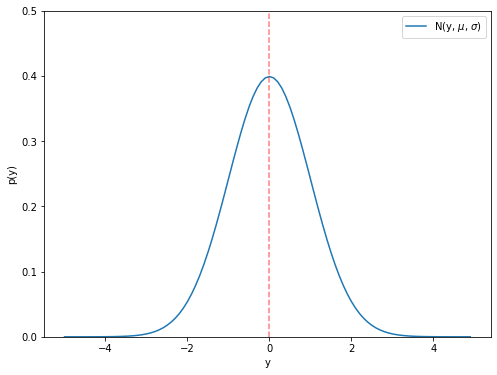

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import math

def normalfördelning(y, mu, sigma):
    return (1/np.sqrt(sigma * 2*math.pi)) * np.exp(-(1/2) * (y - mu)**2 / sigma**2)

y = np.arange(-5, 5, 0.1)
mu, sigma = 0, 1
plt.figure(figsize = (8, 6))
py = normalfördelning(y, mu=mu, sigma=sigma)
plt.plot(y, py, label="N(y, $\mu$, $\sigma$)")
plt.axvline(mu, color='r', ls='--', alpha=0.5)

plt.ylim([0, 0.5])
plt.xlabel('y')
plt.ylabel('p(y)')
plt.legend()
plt.show()

I strikt mening är detta en densitet och sannolikheten för att $y$ ligger i ett intervall $[a,b]$ är
$$
p(y\in[a,b]|\mu,\sigma) = \int_a^b p(y|\mu, \sigma) dy
$$

Vi kommer tala om "sannolikheten" för att $y$ tar något specifikt värde men det är alltså i ovanstående mening.

Alla fördelningar uppfyller att
$$
\int_{-\infty}^{\infty} p(y)dy = 1
$$
dvs sannolikheten för att y tar något värde är 1.

# Model med osäkerhet
Låt oss skapa en modell som förutsäger medelvärde och standardavvikelse istället för en unik prediktion!

Låt $f_\theta : \mathbb{R} \rightarrow \mathbb{R}^2$ vara vår modell med parametrar $\theta$. (I vårt fall kommer det att vara ett neuralt nät)

Låt oss kalla de två komponenterna i $\mathbb{R}^2$ för $f^\mu$ och $f^\sigma$. Så vi har
$$
f_\theta(x) = (f^\mu_\theta(x), f^\sigma_\theta(x))
$$

Vi låter här de två komponenterna motsvara medelvärde och standardavvikelse för en normalförderlning så att vi har
$$
    p(y|x,f_\theta) = \cal{N}(y, f^\mu(x), f^\sigma(x))
$$

Hur tränar vi en sådan här modell?

En fin idé är att vi skulle vilja välja våra parametrar så att vi **maximerar sannolikheten för träningsdatan**.

Ta ett exempel från träningsdatan $(x_i, y_i)$, dvs om vi hade en deterministisk modell så skulle vi vilja att $f(x)=y$.

Här vill vi istället använda vår sannolikhetsbaserade modell och titta på sannolikheten för detta värde:
$$
    p(y_i|x_i,f_\theta) = \cal{N}(y_i, f^\mu_\theta(x_i), f^\sigma_\theta(x_i))
$$

Hur ser det ut om vi försöker maximera denna sannolikhet med avseende på parametrarna $\theta$?

Normalfördelningen innehåller exponentialer, så låt oss också förenkla genom att applicera en logaritm. Eftersom logaritmen är en strikt växande funktion så är det samma sak att maximera detta
$$\max\left[\ln\big(p(y_i | x_i, f_\theta)\big)\right] = \max\left[p(y_i | x_i, f_\theta)\right]$$

$$
\begin{aligned}
    \ln\big(p(y|x, f_\theta)\big) &= \ln\left(\frac{1}{f^\sigma(x) \sqrt{2 \pi}} e^{- \frac{1}{2} \frac{(y -
f^\mu(x))^2}{(f^\sigma(x))^2}}\right)
 \\
    &= \ln\left(e^{- \frac{1}{2} \frac{(y -
f^\mu(x))^2}{(f^\sigma(x))^2}}\right)-\ln\left(f^\sigma(x) \sqrt{2 \pi}\right)
 \\
    &= - \frac{1}{2} \frac{(y -
f^\mu(x))^2}{(f^\sigma(x))^2} -\ln\left(f^\sigma(x)\right) -\ln\left(\sqrt{2 \pi}\right)
\end{aligned}
$$

Att maximera sannolikheten för $(x_i, y_i)$ är samma sak som att maximera en viss version av kvadratiska avvikelsen från medelvärdet $f^\mu(x)$.

Om vi använder negativa logaritmen av sannolikheten $-\ln(p(y|x,f_\theta))$ som det "fel" vi vill minimera så ser det väldigt likt ut det vi redan gjort tidigare.

(På engelska: "negative log-likelyhood".)

*För sannolikheter används logaritmen för att förenkla beräkningarna. Eftersom log-likelihood och sannolikhet ökar/minskar samtidigt, kan vi minimera negativ log-likelihood för att maximera sannolikheten och hitta den bästa modellen.*

## Implementeringsdetalj

Det finns ett litet praktiskt problem med ovanstående samband, nämligen att vi har en divergens när standardavvikelsen $f^\sigma$ närmar sig 0. Detta är ett problem för när vi jobbar med neurala nät som vi har gjort hitils så finns det inget sätt att inskränka ut-värden till att vara strikt positiva, de kan ta värden i hela $\mathbb{R}$.

För att lösa detta kan vi göra ett variabelbyte så att vår modell inte ger ut standardavvikelsen utan logaritmen av standardavvikelsen istället. Då har vi att standardavvikelsen ges av
$$
    \sigma = e^{f^t}
$$
vilket uppfyller att $\sigma > 0$ för alla $f^t \in \mathbb{R}$. Det slutgiltiga sambandet som vi vill minimera blir då

$$
    -\ln\big(p(y|x, f_\theta)\big) = \frac{1}{2} \frac{(y - f^\mu(x)_\theta)^2}{e^{2f^t_\theta}} + f^t_\theta - \ln(\sqrt{2\pi})
$$

där vår modell nu ges av
$$
    f_\theta(x) = (f^\mu_\theta(x), f^t_\theta(x))
$$



## Sannolikheten för all träningsdata

Nu kan vi helt enkelt summera för all träningsdata

$$
p(\text{träningsdata}, f_\theta) = \sum_i p(y_i|x_i,f_\theta)
$$

Att maximera denna sannolikheten är alltså samma sak som att minimera

$$
\min_\theta\left[ -\ln\big(p(\text{träningsdata}, f_\theta)\big)\right]
$$
m.a.p. parametrarna $\theta$.

## Sammanfattning
* Definiera en modell som tar ett tal som indata och två tal som utdata
    * Tolka detta som medelvärde och standardavvikelse för en normalfördelning
* Minimera negativa log-sannolikheten för träningsdatan